<a href="https://colab.research.google.com/github/KimMinWoooo/Hands-on-ML-repo/blob/main/14_deep_computer_vision_with_cnns_2_2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter 14-2 – Deep Computer Vision Using Convolutional Neural Networks**

Homework notebook

### 학번:  20192576

### 이름:  김민우

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [8]:
# Python ≥3.7 is required
import sys
print("Python: ", sys.version_info)
assert sys.version_info >= (3, 7)

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.8 is required
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# GPU test
print("GPU installed: ",tf.test.is_built_with_gpu_support())

# To prevent "CUDNN_STATUS_ALLOC_FAILED" error with GPUs
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Where to save the figures
from pathlib import Path

IMAGES_PATH = Path() / "images" / "11_deep"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

Python:  sys.version_info(major=3, minor=11, micro=12, releaselevel='final', serial=0)
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
GPU installed:  True
Physical devices cannot be modified after being initialized


It also requires Scikit-Learn ≥ 1.0.1:

In [9]:
from packaging import version
import sklearn
print("sklearn version: ", sklearn.__version__)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

sklearn version:  1.6.1


And TensorFlow ≥ 2.8:

In [10]:
import tensorflow as tf
print("TF version: ", tf.__version__)
assert version.parse(tf.__version__) >= version.parse("2.8.0")

TF version:  2.18.0


As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [11]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [ ]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")


In [ ]:
# To prevent "CUDNN_STATUS_ALLOC_FAILED" error with GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


# CNN Architectures

**Tackling Fashion MNIST With a CNN**

In [ ]:
# extra code – loads the mnist dataset, add the channels axis to the inputs,
#              scales the values to the 0-1 range, and splits the dataset
mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = np.expand_dims(X_train_full, axis=-1).astype(np.float32) / 255
X_test = np.expand_dims(X_test.astype(np.float32), axis=-1) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
from functools import partial

tf.random.set_seed(42)  # extra code – ensures reproducibility
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# extra code – compiles, fits, evaluates, and uses the model to make predictions
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
n_epoch=5
# With GPU, train for 10 epochs
# n_epoch=10
history = model.fit(X_train, y_train, epochs=n_epoch,
                    validation_data=(X_valid, y_valid))
# Evaluation
score = model.evaluate(X_test, y_test)
X_new = X_test[:10]  # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.6129 - loss: 1.0803 - val_accuracy: 0.8696 - val_loss: 0.3700
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.8467 - loss: 0.4578 - val_accuracy: 0.8946 - val_loss: 0.3196
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8742 - loss: 0.3717 - val_accuracy: 0.8970 - val_loss: 0.2887
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8900 - loss: 0.3255 - val_accuracy: 0.9026 - val_loss: 0.2697
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9002 - loss: 0.2972 - val_accuracy: 0.9056 - val_loss: 0.2787
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8991 - loss: 0.3090
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step


## LeNet-5

The famous LeNet-5 architecture had the following layers:

Layer  | Type            | Maps | Size     | Kernel size | Stride | Activation
-------|-----------------|------|----------|-------------|--------|-----------
 Out   | Fully connected | –    | 10       | –           | –      | RBF
 F6    | Fully connected | –    | 84       | –           | –      | tanh
 C5    | Convolution     | 120  | 1 × 1    | 5 × 5       | 1      | tanh
 S4    | Avg pooling     | 16   | 5 × 5    | 2 × 2       | 2      | tanh
 C3    | Convolution     | 16   | 10 × 10  | 5 × 5       | 1      | tanh
 S2    | Avg pooling     | 6    | 14 × 14  | 2 × 2       | 2      | tanh
 C1    | Convolution     | 6    | 28 × 28  | 5 × 5       | 1      | tanh
 In    | Input           | 1    | 32 × 32  | –           | –      | –

There were a few tweaks here and there, which don't really matter much anymore, but in case you are interested, here they are:

* MNIST images are 28 × 28 pixels, but they are zero-padded to 32 × 32 pixels and normalized before being fed to the network. The rest of the network does not use any padding, which is why the size keeps shrinking as the image progresses through the network.
* The average pooling layers are slightly more complex than usual: each neuron computes the mean of its inputs, then multiplies the result by a learnable coefficient (one per map) and adds a learnable bias term (again, one per map), then finally applies the activation function.
* Most neurons in C3 maps are connected to neurons in only three or four S2 maps (instead of all six S2 maps). See table 1 (page 8) in the [original paper](https://homl.info/lenet5) for details.
* The output layer is a bit special: instead of computing the matrix multiplication of the inputs and the weight vector, each neuron outputs the square of the Euclidian distance between its input vector and its weight vector. Each output measures how much the image belongs to a particular digit class. The cross-entropy cost function is now preferred, as it penalizes bad predictions much more, producing larger gradients and converging faster.

### Exercise 14.1
- Construct simplified LeNet-5 as shown in the table
- ReLu activation
- Ignore S2->C3 connection and consider regular connection
- Dropout rate: 0.5 for FC
- Output layer: softmax
- Train and evalute the LeNet-5 model and compare the results of the model in the practice code.
![image.png](attachment:image.png)

In [ ]:
#EX.14.1
import tensorflow as tf
from tensorflow import keras
# Define simplified LeNet-5
tf.random.set_seed(42)
np.random.seed(42)

DefaultConv2D_L = partial(keras.layers.Conv2D,
                        kernel_size=5, activation='relu', padding="VALID")
model1 =  keras.models.Sequential([
    DefaultConv2D_L(filters=6, padding="SAME", input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D_L(filters=16),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D_L(filters=120),
    keras.layers.Flatten(),
    keras.layers.Dense(units=84, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile, train and evaluate
model1.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model1.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
score = model1.evaluate(X_test, y_test)
print('\nTest Accuracy:', score)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.6616 - loss: 0.9247 - val_accuracy: 0.8514 - val_loss: 0.4082
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8403 - loss: 0.4588 - val_accuracy: 0.8698 - val_loss: 0.3542
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8687 - loss: 0.3766 - val_accuracy: 0.8648 - val_loss: 0.3512
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8829 - loss: 0.3370 - val_accuracy: 0.8810 - val_loss: 0.3181
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8914 - loss: 0.3076 - val_accuracy: 0.8968 - val_loss: 0.2836
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9000 - loss: 0.2950

Test Accuracy: [0.29750943183898926, 0.8964999914169312]


### Exercise 14.2
1. Construct VGG-like LeNet for MNIST
- 3 conv. Layers: each layer has 2 convolutional 3x3 filters with ReLU activation
  -> in - c1 - c2 - s3 - c4 - c5 - s6 - c7 - c8 - fc - out
- Number of kernels: 6-16-120
- padding: SAME
- Max pooling with 2x2 mask and stride=2
- FC: 84-10.
- Dropout rate: 0.5
- Output: Softmax

Compare results by changing # of kernels, # neurons of FC1, # of conv. layers, batch normalization, and activation functions.

- Compare results with LeNet: Accuracy, Training time

2. Kernal수를 아래와 변경하여 학습후 결과를 비교하시오.  
Number of kernels: 16-32-64

In [ ]:
#Ex. 14.2.1
# Define VGG_like LeNet
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

DefaultConv2D_G = partial(keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding="SAME")
model2 = keras.models.Sequential([
    DefaultConv2D_G(filters=6, input_shape=[28, 28, 1]),
    DefaultConv2D_G(filters=6),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D_G(filters=16),
    DefaultConv2D_G(filters=16),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D_G(filters=120),
    DefaultConv2D_G(filters=120),
    keras.layers.Flatten(),
    keras.layers.Dense(units=84, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 6)      │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 120)      │        17,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 120)      │       129,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5880)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │       494,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,564 (2.46 MB)

 Trainable params: 645,564 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile, train and evaluate
model2.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model2.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
score = model2.evaluate(X_test, y_test)
print('\nTest Accuracy:', score)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7149 - loss: 0.8018 - val_accuracy: 0.8710 - val_loss: 0.3478
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8608 - loss: 0.3924 - val_accuracy: 0.8820 - val_loss: 0.3160
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8830 - loss: 0.3337 - val_accuracy: 0.8900 - val_loss: 0.2986
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8926 - loss: 0.2958 - val_accuracy: 0.8920 - val_loss: 0.2903
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9051 - loss: 0.2639 - val_accuracy: 0.9014 - val_loss: 0.2718
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8964 - loss: 0.3069

Test Accuracy: [0.29325270652770996, 0.8964999914169312]


In [ ]:
# Ex.14.2.2
# Define VGG_like LeNet with different number of kernels
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
model3 = keras.models.Sequential([
    DefaultConv2D_G(filters=16, input_shape=[28, 28, 1]),
    DefaultConv2D_G(filters=16),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D_G(filters=32),
    DefaultConv2D_G(filters=32),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D_G(filters=64),
    DefaultConv2D_G(filters=64),
    keras.layers.Flatten(),
    keras.layers.Dense(units=84, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │       263,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,150 (1.28 MB)

 Trainable params: 336,150 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile, train and evaluate
model3.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model3.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
score = model3.evaluate(X_test, y_test)
print('\nTest Accuracy:', score)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7292 - loss: 0.7641 - val_accuracy: 0.8766 - val_loss: 0.3269
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8732 - loss: 0.3597 - val_accuracy: 0.9028 - val_loss: 0.2637
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8969 - loss: 0.2908 - val_accuracy: 0.9102 - val_loss: 0.2483
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9095 - loss: 0.2578 - val_accuracy: 0.9130 - val_loss: 0.2493
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9176 - loss: 0.2313 - val_accuracy: 0.9148 - val_loss: 0.2489
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9099 - loss: 0.2727

Test Accuracy: [0.26490548253059387, 0.9086999893188477]


# Implementing a ResNet-34 CNN Using Keras

In [ ]:
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [ ]:
# Define ResNet-34
model4 = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=7, strides=2, input_shape=[224, 224, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"),
])
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model4.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model4.add(tf.keras.layers.GlobalAvgPool2D())
model4.add(tf.keras.layers.Flatten())
model4.add(tf.keras.layers.Dense(10, activation="softmax"))
model4.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 56, 56, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 56, 56, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 56, 56, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 28, 28, 128)    │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_4 (ResidualUnit)  │ (None, 28, 28, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_5 (ResidualUnit)  │ (None, 28, 28, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_6 (ResidualUnit)  │ (None, 28, 28, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_7 (ResidualUnit)  │ (None, 14, 14, 256)    │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_8 (ResidualUnit)  │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_9 (ResidualUnit)  │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_10 (ResidualUnit) │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_11 (ResidualUnit) │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_12 (ResidualUnit) │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_13 (ResidualUnit) │ (None, 7, 7, 512)      │     3,676,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_14 (ResidualUnit) │ (None, 7, 7, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_15 (ResidualUnit) │ (None, 7, 7, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,306,826 (81.28 MB)

 Trainable params: 21,289,802 (81.21 MB)

 Non-trainable params: 17,024 (66.50 KB)

### Exercise 14.3  
Resen-34를 이용하여 Fashion MNIST를 학습시키고자 한다.  그러나 ReseNet-34는 ImageNet data aize인 224x224에 맞게 구성되어 있으므로 이를 수정하여야 한다.
1. ResNet-34에 28x28의 Fashion MNSIT data를 입력할 경우 featue size의 변화를 확인하시오.
2. Fashion MNIST data의 경우 크기가 작으므로 첫번째 conv. layer에서 feature size를 줄이는 것은 적합하지 않다. ResNet-34를 수정하여 첫번째 conv. layer에서 feature size를 유지하도록 하고 학습시킨 결과를 확인하고 LeNet-5 및 VGG-like LeNet과 비교하시오.
3. ImageNet을 위한 ResNet-34는 7x7 feature를 GlobalAveragePooling layer를 통과시켰다. Fashion MNIST에 대해서도 동일한 동작을 하도록 high layer를 제거하고 학습결과를 비교하시오. Kernel 수는 low layer로부터 시작한 값을 유지한다.  
(Layer수가 줄었으므로 ResNet-34는 적합하지 않고 ResNet-16이 적합하나 편의상 ResNet-34로 부르기로 한다)
4. 3번에서 kernel수가 64, 128일 때 residual layer를 각각 3, 4개씩 유지하였는데 이를 2, 3개로 줄이고 학습결과를 비교하시오.
5. 2-4번의 결과를 보고 accuracy를 유지하는 범위내에서 네트워크 복잡도를 줄여 학습시간을 최소화하는 ResNet-34를 설계하고 학습결과를 비교하시오.

In [ ]:
# Ex. 14.3.1
# Define ResNet-34 for 28x28 input
DefaultConv2D = partial(keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", use_bias=False)
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
model4a = keras.models.Sequential()
model4a.add(DefaultConv2D(64, kernel_size=7, strides=2,
                        input_shape=[28, 28, 1]))
model4a.add(keras.layers.BatchNormalization())
model4a.add(keras.layers.Activation("relu"))
model4a.add(keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"))
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model4a.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters
model4a.add(keras.layers.GlobalAvgPool2D())
model4a.add(keras.layers.Flatten())
model4a.add(keras.layers.Dense(10, activation="softmax"))
model4a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 7, 7, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 7, 7, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 7, 7, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 4, 4, 128)      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_4 (ResidualUnit)  │ (None, 4, 4, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_5 (ResidualUnit)  │ (None, 4, 4, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_6 (ResidualUnit)  │ (None, 4, 4, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_7 (ResidualUnit)  │ (None, 2, 2, 256)      │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_8 (ResidualUnit)  │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_9 (ResidualUnit)  │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_10 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_11 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_12 (ResidualUnit) │ (None, 2, 2, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_13 (ResidualUnit) │ (None, 1, 1, 512)      │     3,676,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_14 (ResidualUnit) │ (None, 1, 1, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_15 (ResidualUnit) │ (None, 1, 1, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,300,554 (81.26 MB)

 Trainable params: 21,283,530 (81.19 MB)

 Non-trainable params: 17,024 (66.50 KB)

In [ ]:
# Ex. 14.3.2
# Modify ResNet-34
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
model4a = keras.models.Sequential()
model4a.add(DefaultConv2D(64, kernel_size=7, strides=1,
                        input_shape=[28, 28, 1]))
model4a.add(keras.layers.BatchNormalization())
model4a.add(keras.layers.Activation("relu"))
model4a.add(keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"))
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model4a.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters
model4a.add(keras.layers.GlobalAvgPool2D())
model4a.add(keras.layers.Flatten())
model4a.add(keras.layers.Dense(10, activation="softmax"))
model4a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 7, 7, 128)      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_4 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_5 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_6 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_7 (ResidualUnit)  │ (None, 4, 4, 256)      │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_8 (ResidualUnit)  │ (None, 4, 4, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_9 (ResidualUnit)  │ (None, 4, 4, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_10 (ResidualUnit) │ (None, 4, 4, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_11 (ResidualUnit) │ (None, 4, 4, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_12 (ResidualUnit) │ (None, 4, 4, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_13 (ResidualUnit) │ (None, 2, 2, 512)      │     3,676,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_14 (ResidualUnit) │ (None, 2, 2, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_15 (ResidualUnit) │ (None, 2, 2, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,300,554 (81.26 MB)

 Trainable params: 21,283,530 (81.19 MB)

 Non-trainable params: 17,024 (66.50 KB)

In [ ]:
model4a.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model4a.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
score = model4a.evaluate(X_test, y_test)
print('\nTest Accuracy:', score)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 136s 58ms/step - accuracy: 0.7998 - loss: 0.5868 - val_accuracy: 0.8894 - val_loss: 0.3158
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 114s 49ms/step - accuracy: 0.8891 - loss: 0.3064 - val_accuracy: 0.8786 - val_loss: 0.3334
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 140s 47ms/step - accuracy: 0.9029 - loss: 0.2705 - val_accuracy: 0.8968 - val_loss: 0.3201
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 79s 46ms/step - accuracy: 0.9141 - loss: 0.2421 - val_accuracy: 0.8986 - val_loss: 0.2697
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.9258 - loss: 0.2007 - val_accuracy: 0.9012 - val_loss: 0.2628
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8976 - loss: 0.2896

Test Accuracy: [0.2853511571884155, 0.8970999717712402]


In [ ]:
# Ex. 14.3.3
# Modify ResNet-34
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
model4b = keras.models.Sequential()
model4b.add(DefaultConv2D(64, kernel_size=7, strides=1,
                        input_shape=[28, 28, 1]))
model4b.add(keras.layers.BatchNormalization())
model4b.add(keras.layers.Activation("relu"))
model4b.add(keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"))
prev_filters = 64
for filters in [64] * 3 + [128] * 4:
    strides = 1 if filters == prev_filters else 2
    model4b.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters
model4b.add(keras.layers.GlobalAvgPool2D())
model4b.add(keras.layers.Flatten())
model4b.add(keras.layers.Dense(10, activation="softmax"))
model4b.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 7, 7, 128)      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_4 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_5 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_6 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,346,122 (5.14 MB)

 Trainable params: 1,342,922 (5.12 MB)

 Non-trainable params: 3,200 (12.50 KB)

In [ ]:
model4b.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model4b.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
score = model4b.evaluate(X_test, y_test)
print('\nTest Accuracy:', score)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.8121 - loss: 0.5272 - val_accuracy: 0.8506 - val_loss: 0.4443
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8921 - loss: 0.2912 - val_accuracy: 0.7880 - val_loss: 0.6918
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9085 - loss: 0.2465 - val_accuracy: 0.9028 - val_loss: 0.2760
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9200 - loss: 0.2153 - val_accuracy: 0.8866 - val_loss: 0.3499
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9316 - loss: 0.1877 - val_accuracy: 0.9096 - val_loss: 0.2542
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8993 - loss: 0.2807

Test Accuracy: [0.2760664224624634, 0.9013000130653381]


In [ ]:
# Ex. 14.3.4
# Modify ResNet-34
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
model4c = keras.models.Sequential()
model4c.add(DefaultConv2D(64, kernel_size=7, strides=1,
                        input_shape=[28, 28, 1]))
model4c.add(keras.layers.BatchNormalization())
model4c.add(keras.layers.Activation("relu"))
model4c.add(keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"))
prev_filters = 64
for filters in [64] * 2 + [128] * 3:
    strides = 1 if filters == prev_filters else 2
    model4c.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters
model4c.add(keras.layers.GlobalAvgPool2D())
model4c.add(keras.layers.Flatten())
model4c.add(keras.layers.Dense(10, activation="softmax"))
model4c.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 7, 7, 128)      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_4 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 975,946 (3.72 MB)

 Trainable params: 973,514 (3.71 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
model4c.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model4c.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
score = model4c.evaluate(X_test, y_test)
print('\nTest Accuracy:', score)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - accuracy: 0.8103 - loss: 0.5317 - val_accuracy: 0.8644 - val_loss: 0.3873
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8932 - loss: 0.2959 - val_accuracy: 0.8700 - val_loss: 0.3497
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9087 - loss: 0.2497 - val_accuracy: 0.8906 - val_loss: 0.3090
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9200 - loss: 0.2170 - val_accuracy: 0.8888 - val_loss: 0.3069
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9301 - loss: 0.1901 - val_accuracy: 0.8954 - val_loss: 0.3041
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8932 - loss: 0.3174

Test Accuracy: [0.31703099608421326, 0.8906000256538391]


In [ ]:
# Ex. 14.3.5
# Modify ResNet-34
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
model4d = keras.models.Sequential()
model4d.add(DefaultConv2D(32, kernel_size=3, strides=1, input_shape=[28, 28, 1]))
model4d.add(DefaultConv2D(32, kernel_size=3, strides=1, input_shape=[28, 28, 32]))
model4d.add(keras.layers.BatchNormalization())
model4d.add(keras.layers.Activation("relu"))
model4d.add(keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"))
prev_filters = 32
for filters in [32] * 1 + [64] * 1:
    strides = 1 if filters == prev_filters else 2
    model4d.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters
model4d.add(keras.layers.GlobalAvgPool2D())
model4d.add(keras.layers.Flatten())
model4d.add(keras.layers.Dense(10, activation="softmax"))
model4d.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 14, 14, 32)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 7, 7, 64)       │        58,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,082 (340.16 KB)

 Trainable params: 86,506 (337.91 KB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
model4d.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model4d.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
score = model4d.evaluate(X_test, y_test)
print('\nTest Accuracy:', score)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.7817 - loss: 0.6569 - val_accuracy: 0.8514 - val_loss: 0.4278
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8846 - loss: 0.3214 - val_accuracy: 0.8746 - val_loss: 0.3591
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9034 - loss: 0.2716 - val_accuracy: 0.8956 - val_loss: 0.2971
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9141 - loss: 0.2420 - val_accuracy: 0.9008 - val_loss: 0.2889
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9224 - loss: 0.2203 - val_accuracy: 0.8916 - val_loss: 0.3011
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8847 - loss: 0.3215

Test Accuracy: [0.3279474675655365, 0.8801000118255615]


# Using Pretrained Models from Keras

In [ ]:
# Defien ResNet-50 using Keras with pre-trained weight of ImageNet
model5 = tf.keras.applications.ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


**Warning**: The expression `load_sample_images()["images"]` returns a Python list of images. However, in the latest versions, Keras does not accept Python lists anymore, so we must convert this list to a tensor. We can do this using `tf.constant()`, but here I have used `K.constant()` instead: it simply calls `tf.constant()` if you are using TensorFlow as the backend (as is the case here), but if you ever decide to use JAX or PyTorch as the backend instead, `K.constant()` will call the appropriate function from the chosen backend.

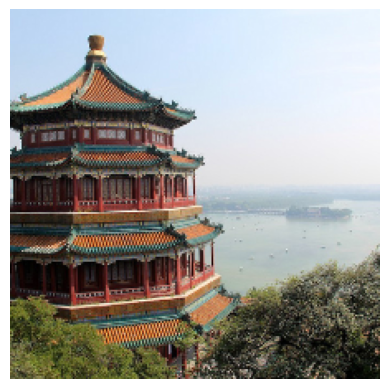

In [ ]:
# Resize image to 224x224 (image size of ImageNet sample)
from sklearn.datasets import load_sample_images
K = tf.keras.backend
images = K.constant(load_sample_images()["images"])
images_resized = tf.keras.layers.Resizing(height=224, width=224,
                                          crop_to_aspect_ratio=True)(images)
plt.imshow(images_resized[0]/255)
plt.axis("off")
#plot_color_image(images_resized[0])
plt.show()

In [ ]:
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized)

In [ ]:
Y_proba = model5.predict(inputs)
Y_proba.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


(2, 1000)

In [ ]:
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Image #0
  n03877845 - palace       54.69%
  n03781244 - monastery    24.71%
  n02825657 - bell_cote    18.55%
Image #1
  n04522168 - vase         32.67%
  n11939491 - daisy        17.82%
  n03530642 - honeycomb    12.04%


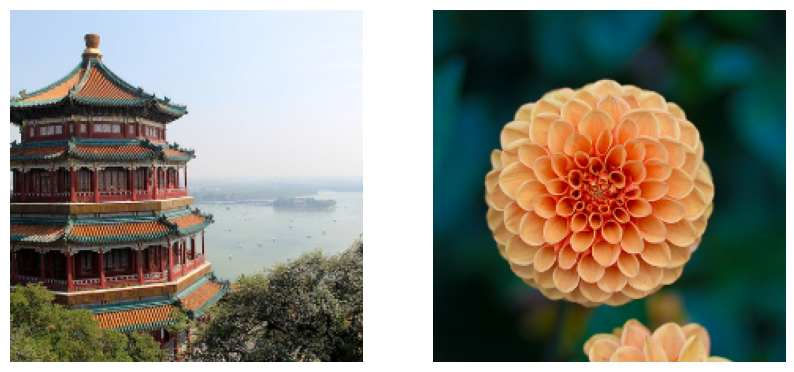

In [ ]:
# extra code – displays the cropped and resized images

plt.figure(figsize=(10, 6))
for idx in (0, 1):
    plt.subplot(1, 2, idx + 1)
    plt.imshow(images_resized[idx] / 255)
    plt.axis("off")

plt.show()

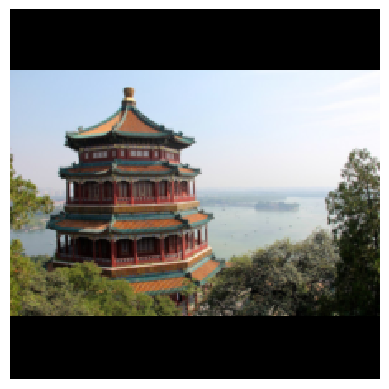

In [ ]:
# Resize keeping aspect ratio, and padding with 0
def plot_color_image(image):
    plt.imshow(image, interpolation="nearest")
    plt.axis("off")
images_resized = tf.image.resize_with_pad(images, 224, 224, antialias=True)
plot_color_image(images_resized[0]/255)

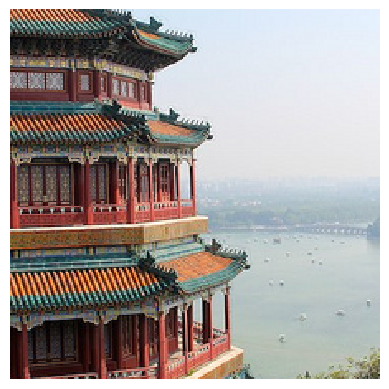

In [ ]:
# Centrally crop the image. If original image is smaller, resize with padding.
images_resized = tf.image.resize_with_crop_or_pad(images, 224, 224)
plot_color_image(images_resized[0]/255)
plt.show()

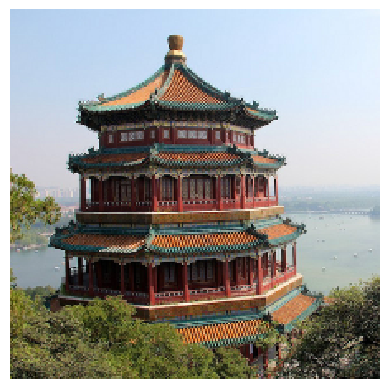

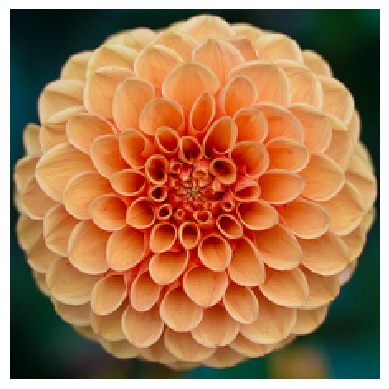

In [ ]:
# Crop and resize an image using a specified box
china_box = [0, 0.03, 1, 0.68]
flower_box = [0.19, 0.26, 0.86, 0.7]
images_resized = tf.image.crop_and_resize(images, [china_box, flower_box], [0, 1], [224, 224])
plot_color_image(images_resized[0]/255)
plt.show()
plot_color_image(images_resized[1]/255)
plt.show()

# Pretrained Models for Transfer Learning

In [1]:
# # 데이터 경로 설정
# data_directory = 'datasets/tf_flower'

# # 학습 데이터를 로드하여 데이터셋 만들기 (dim=[batch, H, W, C])
# dataset = tf.keras.preprocessing.image_dataset_from_directory(
#     data_directory,
#     image_size=(224, 224),  # 이미지 크기 조정
#     batch_size=1  # 배치 크기
# )

# # 데이터셋 정보 출력
# class_names = dataset.class_names
# print(f'클래스 이름: {class_names}')

In [ ]:
# 데이터셋 정보 저장
dataset_size = sum(1 for _ in dataset.unbatch())  # 전체 데이터 수 계산
n_classes = len(dataset.class_names)  # 클래스 수 계산

# 결과 출력
print(f'데이터 수: {dataset_size}')
print(f'클래스 수: {n_classes}')

In [ ]:
# 데이터셋을 train, validation, test로 분리
dataset=dataset.unbatch()
test_size = int(dataset_size * 0.1)        # 10% 테스트 세트
valid_size = int(dataset_size * 0.15)      # 15% 검증 세트
train_size = dataset_size - test_size - valid_size  # 나머지는 훈련 세트

# 데이터셋을 나누기 위해 인덱스를 생성
dataset = dataset.shuffle(buffer_size=dataset_size, seed=42)  # 섞기

test_set_raw = dataset.take(test_size)  # 첫 10%를 테스트 세트로
valid_set_raw = dataset.skip(test_size).take(valid_size)  # 다음 15%를 검증 세트로
train_set_raw = dataset.skip(test_size + valid_size)  # 나머지를 훈련 세트로

# 결과 출력
print(f'총 데이터 수: {dataset_size}, 테스트 수: {test_size}, 검증 수: {valid_size}, 훈련 수: {train_size}')

In [2]:
# Higher version
import tensorflow_datasets as tfds
print(tfds.__version__)
dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

4.9.8


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.MJ5I4T_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [3]:
dataset_size

3670

In [4]:
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [5]:
n_classes

5

In [6]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
   "tf_flowers",
   split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
   as_supervised=True)

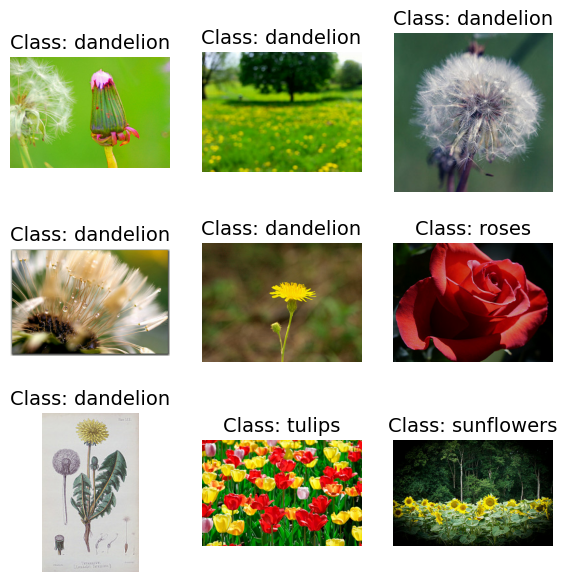

In [12]:
# extra code – displays the first 9 images in the validation set
plt.imshow
plt.figure(figsize=(7, 7))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")
#    print(class_names[label])
plt.show()

All three datasets contain individual images. We need to batch them, but for this we first need to ensure they all have the same size, or else batching will not work. We can use a `Resizing` layer for this. We must also call the `tf.keras.applications.xception.preprocess_input()` function to preprocess the images appropriately for the Xception model. We will also add shuffling and prefetching to the training dataset.

In [13]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter
#train_set_raw=train_set_raw.unbatch()
#valid_set_raw=valid_set_raw.unbatch()
#test_set_raw=test_set_raw.unbatch()
batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

Let's take a look again at the first 9 images from the validation set: they're all 224x224 now, with values ranging from -1 to 1:

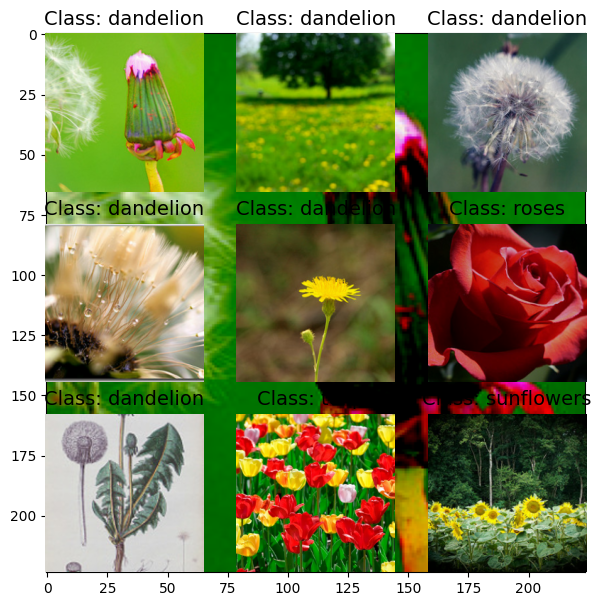

In [14]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(7, 7))
for X_batch, y_batch in valid_set.take(1):
    plt.imshow((X_batch[0]))
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

Try running the following cell multiple times to see different random data augmentations:

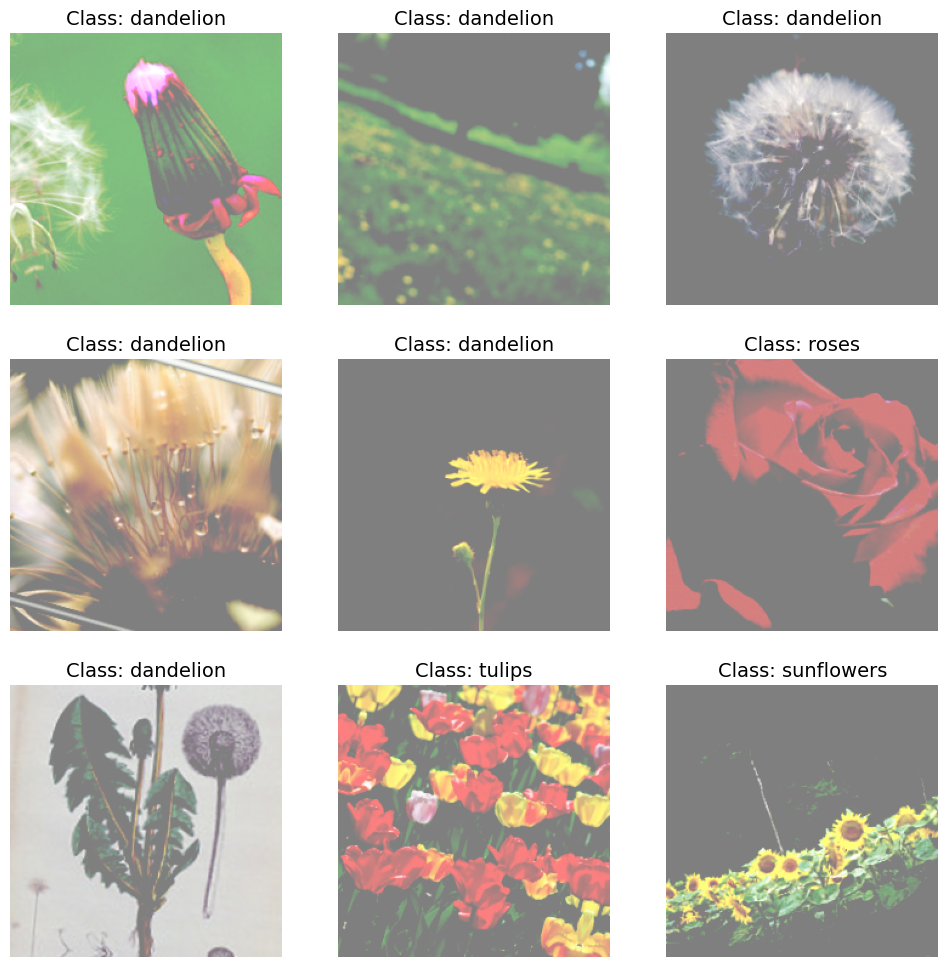

In [28]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

Now let's load the pretrained model, without its top layers, and replace them with our own, for the flower classification task:

In [17]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model6 = tf.keras.Model(inputs=base_model.input, outputs=output)
model6.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │      8,192 │ block1_conv2_act… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ block2_pool[0][0… │
│                     │ None, 128)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ add[0][0]       

 Total params: 20,871,725 (79.62 MB)

 Trainable params: 20,817,197 (79.41 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [18]:
for layer in base_model.layers:
    layer.trainable = False

Let's train the model for a few epochs, while keeping the base model weights fixed:

In [19]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model6.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model6.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 33s 208ms/step - accuracy: 0.6929 - loss: 1.0995 - val_accuracy: 0.8348 - val_loss: 0.7155
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.9103 - loss: 0.3529 - val_accuracy: 0.8603 - val_loss: 0.5999
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9327 - loss: 0.2149 - val_accuracy: 0.8639 - val_loss: 0.5879


In [20]:
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

  0: input_layer_2          33: block4_pool            66: block8_sepconv1_act    99: block11_sepconv2_act  
  1: block1_conv1           34: batch_normalization_2  67: block8_sepconv1       100: block11_sepconv2      
  2: block1_conv1_bn        35: add_2                  68: block8_sepconv1_bn    101: block11_sepconv2_bn   
  3: block1_conv1_act       36: block5_sepconv1_act    69: block8_sepconv2_act   102: block11_sepconv3_act  
  4: block1_conv2           37: block5_sepconv1        70: block8_sepconv2       103: block11_sepconv3      
  5: block1_conv2_bn        38: block5_sepconv1_bn     71: block8_sepconv2_bn    104: block11_sepconv3_bn   
  6: block1_conv2_act       39: block5_sepconv2_act    72: block8_sepconv3_act   105: add_9                 
  7: block2_sepconv1        40: block5_sepconv2        73: block8_sepconv3       106: block12_sepconv1_act  
  8: block2_sepconv1_bn     41: block5_sepconv2_bn     74: block8_sepconv3_bn    107: block12_sepconv1      
  9: block2_sepconv

Now that the weights of our new top layers are not too bad, we can make the top part of the base model trainable again, and continue training, but with a lower learning rate:

In [21]:
for layer in base_model.layers[56:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model6.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model6.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 46s 331ms/step - accuracy: 0.8693 - loss: 0.3719 - val_accuracy: 0.8748 - val_loss: 0.6339
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - accuracy: 0.9777 - loss: 0.0621 - val_accuracy: 0.9020 - val_loss: 0.3040
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 296ms/step - accuracy: 0.9965 - loss: 0.0162 - val_accuracy: 0.9093 - val_loss: 0.2842
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 294ms/step - accuracy: 0.9957 - loss: 0.0090 - val_accuracy: 0.9183 - val_loss: 0.2953
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 295ms/step - accuracy: 0.9982 - loss: 0.0065 - val_accuracy: 0.9074 - val_loss: 0.3631
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 304ms/step - accuracy: 0.9988 - loss: 0.0034 - val_accuracy: 0.9093 - val_loss: 0.3024
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 309ms/step - accuracy: 0.9995 - loss: 0.0052 - val_accuracy: 0.9093 - val_loss: 0.3267
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 302ms/step - accuracy: 0.9999 - loss: 0.0016 - val_accu

### Exercise 14.4   
1. 위의 셀들을 참조하여 base_model을 MobileNet으로 변경하여 학습시키시오.  
2. Xception과 학습시간 및 정확도를 비교하시오.

In [23]:
#Ex14.4.1
import tensorflow as tf
from tensorflow import keras
keras.backend.clear_session()
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.mobilenet.MobileNet(weights="imagenet", include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model7 = tf.keras.Model(inputs=base_model.input, outputs=output)
for index, layer in enumerate(base_model.layers):
    print(index, layer.name)

<ipython-input-23-0444ba97a83d>:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.mobilenet.MobileNet(weights="imagenet", include_top=False)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
0 input_layer
1 conv1
2 conv1_bn
3 conv1_relu
4 conv_dw_1
5 conv_dw_1_bn
6 conv_dw_1_relu
7 conv_pw_1
8 conv_pw_1_bn
9 conv_pw_1_relu
10 conv_pad_2
11 conv_dw_2
12 conv_dw_2_bn
13 conv_dw_2_relu
14 conv_pw_2
15 conv_pw_2_bn
16 conv_pw_2_relu
17 conv_dw_3
18 conv_dw_3_bn
19 conv_dw_3_relu
20 conv_pw_3
21 conv_pw_3_bn
22 conv_pw_3_relu
23 conv_pad_4
24 conv_dw_4
25 conv_dw_4_bn
26 conv_dw_4_relu
27 conv_pw_4
28 conv_pw_4_bn
29 conv_pw_4_relu
30 conv_dw_5
31 conv_dw_5_bn
32 conv_dw_5_relu
33 conv_pw_5
34 conv_pw_5_bn
35 conv_pw_5_relu
36 conv_pad_6
37 conv_dw_6
38 conv_dw_6_bn
39 conv_dw_6_relu
40 conv_pw_6
41 conv_pw_6_bn
42 conv_pw_6_relu
43 conv_dw_7
44 conv_dw_7_bn
45 conv_dw_7_relu
46 conv_pw_7
47 conv_pw_7_bn
48 conv_pw_7_relu
49 conv_dw_8
50 conv_dw_8_bn
51 conv_dw_8_relu
52 conv_pw_8
53 conv_pw_8_bn
54 conv_pw_8_relu
55 conv_dw_9
56 conv_dw_9_bn
57 conv_dw_9_relu
58 conv_pw_9
59 conv_pw_9_bn
60 conv_pw_9_relu
61 conv_dw_10
62 conv

In [25]:
# Compile and train top dense layer only

for layer in base_model.layers:
    layer.trainable = False

optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9)
#optimizer = keras.optimizers.legacy.SGD(learning_rate=0.2, momentum=0.9, decay=0.01)
model7.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model7.fit(train_set,
#                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
#                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=3)

Epoch 1/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.6921 - loss: 6.8714 - val_accuracy: 0.7677 - val_loss: 8.1660
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8849 - loss: 3.3057 - val_accuracy: 0.8621 - val_loss: 5.0173
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9369 - loss: 1.3473 - val_accuracy: 0.8748 - val_loss: 4.9032


In [26]:
# Compile and train all layers
for layer in base_model.layers:
    layer.trainable = True

optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
#optimizer = keras.optimizers.legacy.SGD(learning_rate=0.01, momentum=0.9, nesterov=True, decay=0.001)
model7.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model7.fit(train_set,
#                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
#                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - accuracy: 0.3588 - loss: 30.3634 - val_accuracy: 0.2087 - val_loss: 32.0775
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.3392 - loss: 2.3913 - val_accuracy: 0.2577 - val_loss: 14.7110
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.3984 - loss: 1.7353 - val_accuracy: 0.3920 - val_loss: 2.1904
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.4774 - loss: 1.5628 - val_accuracy: 0.4120 - val_loss: 1.7770
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.5273 - loss: 1.3630 - val_accuracy: 0.4846 - val_loss: 1.4716
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.5668 - loss: 1.2263 - val_accuracy: 0.5281 - val_loss: 1.3112
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.5999 - loss: 1.1158 - val_accuracy: 0.5753 - val_loss: 1.1412
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.6102 - loss: 1.0781 - val_accuracy: 0.62

#### Ex14.4.2  
Answer: MobileNet은 훨씬 빠르고 가볍지만 정확도 측면에서는 base_model에 비해서 더 좋지 못함